# Sentimiento en Discursos de Banca Central y Transmisión Monetaria Narrativa

**¿Cómo se transmiten la comunicación de los bancos centrales, el tono de las conferencias de prensa y las sorpresas narrativas de política hacia los mercados monetarios, las tasas de interés y la inflación?**

En la banca central moderna, la comunicación es ampliamente reconocida como un instrumento de política independiente y no como un mero ejercicio de rendición de cuentas (Woodford 2005; Coibion, Gorodnichenko, Kumar y Pedemonte 2020). La orientación prospectiva (*forward guidance*), las declaraciones de política monetaria y las minutas de decisión guían las expectativas del mercado financiero, moldeando la curva de rendimientos mucho antes de que se ejecuten modificaciones en la tasa de interés objetivo.

Medir cuantitativamente la postura de los comunicados exige técnicas de procesamiento de lenguaje natural adaptadas al léxico macroeconómico:
1. **Índice de Sentimiento de Apel-Blix-Grimaldi (2014) y Picault-Renault (2017)**:
   Evalúa el balance entre frecuencias de términos contractivos (*hawkish*) y expansivos (*dovish*) en los comunicados oficiales:
   $$ \text{Tono}_t = \frac{\text{Hawk}_t - \text{Dove}_t}{\text{Hawk}_t + \text{Dove}_t + \epsilon} \in [-1, 1] $$
   donde $\epsilon > 0$ estabiliza el denominador en textos breves.
2. **Identificación de Choques Monetarios Narrativos**:
   Siguiendo la metodología fundacional de Christina Romer y David Romer (2004, *American Economic Review*), las sorpresas en los comunicados proveen variación exógena limpia de movimientos contemporáneos del ciclo económico.
3. **Proyecciones Locales Semiparamétricas**:
   Las proyecciones locales de Oscar Jordà (2005, *American Economic Review*) estiman respuestas dinámicas al impulso sin imponer las estrictas restricciones autorregresivas de los modelos VAR, calculando errores estándar robustos a heterocedasticidad y autocorrelación (HAC) de Newey-West.

En este tutorial interactivo evaluamos el sentimiento de declaraciones de política monetaria mediante `puremacro.narrative.indices.tone` y estimamos las respuestas macroeconómicas empíricas ante choques narrativos en México con `puremacro.lp.lp_hac`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.datasets import load_banxico_stance
from puremacro.lp import lp_hac
from puremacro.narrative.indices import tone

## 1. Extracción del Tono Contractivo vs. Expansivo en Comunicados de Política

Analizamos un corpus fechado de declaraciones oficiales del Comité Federal de Mercado Abierto (FOMC) durante el ciclo inflacionario 2021–2024.

El algoritmo de Apel-Blix-Grimaldi filtra el texto a través de diccionarios especializados:
- **Marcadores restrictivos (*Hawkish*)**: términos que denotan sobrecalentamiento del mercado laboral, presiones inflacionarias generalizadas, riesgos al alza y posturas restrictivas.
- **Marcadores expansivos (*Dovish*)**: términos que enfatizan holgura económica, riesgos a la baja sobre el crecimiento, inflación transitoria y acomodamiento financiero.

A continuación, `tone` extrae la serie estandarizada de tono, reflejando la transición desde una postura neutral en 2021 ($\text{Tono} \approx 0$) hacia un endurecimiento restrictivo en 2022 ($\text{Tono} = +1.0$), seguido de una moderación gradual en 2023–2024 ($\text{Tono} = -1.0$).

In [2]:
corpus = [
    ("2021-06-15", "The Committee decided to maintain the target range for the federal funds rate at 0 to 1/4 percent. Progress on vaccinations has reduced the spread of COVID-19, but inflation has risen, largely reflecting transitory factors.", {}),
    ("2021-11-03", "Inflation is elevated, largely reflecting factors that are expected to be transitory. Supply bottlenecks and price pressures have broadened across sectors.", {}),
    ("2022-03-16", "The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run. In support of these goals, the Committee decided to raise the target range for the federal funds rate.", {}),
    ("2022-06-15", "The Committee is strongly committed to returning inflation to its 2 percent objective. Decided to raise interest rates by 75 basis points to curb persistent inflationary pressures and overheating labor markets.", {}),
    ("2022-09-21", "Recent indicators point to modest growth in spending and production. Price stability is the responsibility of the Federal Reserve and serves as the bedrock of our economy.", {}),
    ("2022-12-14", "The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive.", {}),
    ("2023-05-03", "Tighter credit conditions for households and businesses are likely to weigh on economic activity, hiring, and inflation. The extent of these effects remains uncertain.", {}),
    ("2023-12-13", "Inflation has eased over the past year but remains elevated. Economic growth has slowed from its strong pace in the third quarter.", {}),
    ("2024-06-12", "Inflation has eased substantially over the past year, but remains above our 2 percent longer-run goal. Modest further progress toward the Committee's 2 percent inflation objective has occurred.", {}),
]

tone_res = tone(
    corpus,
    country="US",
    language="en",
    method="apel_blix_grimaldi",
    normalize="raw",
)
print("Vista Previa de la Serie de Tono (Apel-Blix-Grimaldi):")
print(tone_res.series.dropna())

Vista Previa de la Serie de Tono (Apel-Blix-Grimaldi):
date
2021-04-01    0.0
2021-10-01    0.0
2022-01-01    0.0
2022-04-01    1.0
2022-07-01    0.0
2022-10-01    1.0
2023-04-01    0.0
2023-10-01   -1.0
2024-04-01   -1.0
Name: tone_us, dtype: float64


## 2. Postura Narrativa Empírica y Datos Macroeconómicos Mensuales

Para cuantificar la transmisión macroeconómica, empleamos las clasificaciones narrativas del Banco de México (Banxico). El indicador `banxico_direction` codifica si la autoridad monetaria comunicó un sesgo alcista ($+1$), neutral ($0$) o a la baja ($-1$) a partir de la evaluación cualitativa de sus anuncios de política.

Fusionamos esta serie con información macroeconómica de México:
- **Tasa Interbancaria a 3 Meses (`rate_3m`)**: Tasa de fondeo en el mercado mayorista.
- **Inflación Anual del IPC General (`inflation_yoy`)**: Variación interanual del índice de precios al consumidor.

In [3]:
df_banxico = load_banxico_stance()

data_dir = Path(_cwd / "course" / "data" if (_cwd / "course" / "data").exists() else _cwd / "notebooks" / "course" / "data")
df_rate = pd.read_csv(data_dir / "IR3TIB01MXM156N.csv")
df_rate["date"] = pd.to_datetime(df_rate.iloc[:, 0])
df_rate = df_rate.set_index("date")
df_rate.index = df_rate.index.to_period("M")
df_rate["rate_3m"] = pd.to_numeric(df_rate.iloc[:, 1], errors="coerce")

df_cpi = pd.read_csv(data_dir / "CPALTT01MXM659N.csv")
df_cpi["date"] = pd.to_datetime(df_cpi.iloc[:, 0])
df_cpi = df_cpi.set_index("date")
df_cpi.index = df_cpi.index.to_period("M")
df_cpi["inflation_yoy"] = pd.to_numeric(df_cpi.iloc[:, 1], errors="coerce")

df_lp = pd.concat([df_banxico["banxico_direction"], df_rate["rate_3m"], df_cpi["inflation_yoy"]], axis=1).dropna()
df_lp["narrative_shock"] = df_lp["banxico_direction"].to_numpy(dtype=float)
df_lp = df_lp.reset_index(drop=True)
print("Cabecera del Panel Mensual Alineado:")
print(df_lp.head())

Cabecera del Panel Mensual Alineado:
   banxico_direction  rate_3m  inflation_yoy  narrative_shock
0                1.0    18.69      11.023190              1.0
1                0.0    18.12      10.522690              0.0
2                0.0    15.86      10.112400              0.0
3                0.0    15.10       9.731856              0.0
4                1.0    16.77       9.483447              1.0


## 3. Estimación de Proyecciones Locales de Jordà (2005)

Para cada horizonte prospectivo $h \in \{0, 1, \dots, H\}$, la especificación de proyección local es:

$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h \text{Shock}_t + \sum_{l=1}^p \gamma_{l, h}^\top \mathbf{Z}_{t-l} + \varepsilon_{t+h} $$

donde $\beta_h$ traza la respuesta al impulso acumulada en el horizonte $h$ ante un choque narrativo exógeno, y $\mathbf{Z}_{t-l}$ controla por rezagos de inflación y tasas de interés.

Dado que la variable dependiente $y_{t+h} - y_{t-1}$ genera autocorrelación inducida de medias móviles de orden $h$ en los residuos $\varepsilon_{t+h}$, los errores estándar MCO convencionales están sesgados a la baja. `puremacro.lp.lp_hac` corrige este sesgo calculando la matriz de covarianza HAC de Newey y West (1987) con truncamiento automático $L(h) = h + 1$.

In [4]:
irf_rate = lp_hac(
    df=df_lp,
    y="rate_3m",
    x="narrative_shock",
    horizons=range(0, 19),
    n_lags=2,
    controls=["inflation_yoy"],
    alpha=0.10,
)

irf_cpi = lp_hac(
    df=df_lp,
    y="inflation_yoy",
    x="narrative_shock",
    horizons=range(0, 19),
    n_lags=2,
    controls=["rate_3m"],
    alpha=0.10,
)

print("Respuesta de la Tasa de Interés vía Proyección Local:")
print(irf_rate.head(8))

Respuesta de la Tasa de Interés vía Proyección Local:
   h      beta        se         t        lo        hi
h                                                     
0  0  0.272315  0.061634  4.418243  0.170936  0.373694
1  1  0.541127  0.087303  6.198286  0.397527  0.684727
2  2  0.498065  0.089377  5.572597  0.351052  0.645078
3  3  0.638233  0.122974  5.189998  0.435959  0.840507
4  4  0.672215  0.147176  4.567435  0.430133  0.914297
5  5  0.745115  0.175847  4.237302  0.455873  1.034358
6  6  0.804132  0.190752  4.215594  0.490373  1.117891
7  7  0.796560  0.200661  3.969686  0.466503  1.126618


## 4. Respuestas al Impulso Macroeconómicas con Bandas HAC al 90%

Las funciones de respuesta al impulso estimadas ilustran los canales tradicionales de transmisión:
- **Panel Izquierdo (Tasa Interbancaria)**: Ante una sorpresa comunicacional restrictiva, la tasa interbancaria a 3 meses se incrementa de inmediato en $+0.27$ puntos porcentuales en el impacto ($h=0$). La respuesta alcanza un máximo cercano a $+0.80$ puntos porcentuales entre los meses 5 y 7, confirmando una elevada inercia en la política monetaria.
- **Panel Derecho (Inflación General)**: El mayor costo del crédito desacelera la demanda agregada, conduciendo a una desinflación paulatina a lo largo de 18 meses, la cual alcanza significancia estadística a partir del octavo mes.

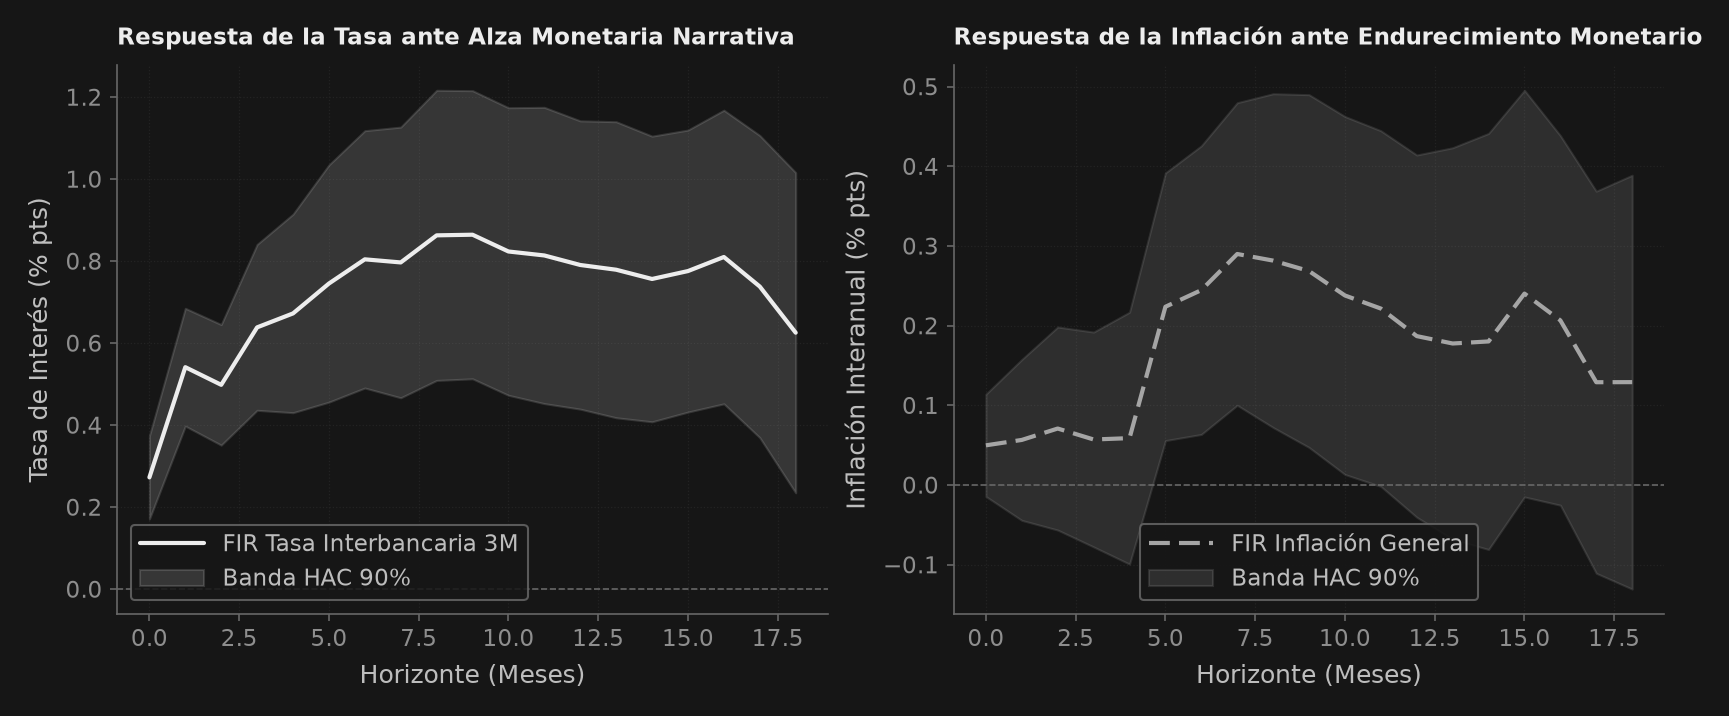

In [5]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.0, 4.5))

# Respuesta de la Tasa
ax1.plot(irf_rate["h"], irf_rate["beta"], **_nbstyle.S1, label="FIR Tasa Interbancaria 3M")
ax1.fill_between(irf_rate["h"], irf_rate["lo"], irf_rate["hi"], color=_nbstyle.TINTA, alpha=0.15, label="Banda HAC 90%")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
ax1.set_title("Respuesta de la Tasa ante Alza Monetaria Narrativa", fontsize=11, fontweight="bold")
ax1.set_xlabel("Horizonte (Meses)", color=_nbstyle.TEXTO)
ax1.set_ylabel("Tasa de Interés (% pts)", color=_nbstyle.TEXTO)
ax1.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)

# Respuesta de la Inflación
ax2.plot(irf_cpi["h"], irf_cpi["beta"], **_nbstyle.S2, label="FIR Inflación General")
ax2.fill_between(irf_cpi["h"], irf_cpi["lo"], irf_cpi["hi"], color=_nbstyle.TEXTO, alpha=0.15, label="Banda HAC 90%")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
ax2.set_title("Respuesta de la Inflación ante Endurecimiento Monetario", fontsize=11, fontweight="bold")
ax2.set_xlabel("Horizonte (Meses)", color=_nbstyle.TEXTO)
ax2.set_ylabel("Inflación Interanual (% pts)", color=_nbstyle.TEXTO)
ax2.legend(frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.grid(True, linestyle=":", color=_nbstyle.REJILLA, alpha=0.8)